# Week 03: The JAX Ecosystem

Last week we established that `grad` is cheap: one reverse pass, same order of cost as
the function itself. That is the engine. But an engine is not a car. To train anything
you also need somewhere to *put* the parameters, a rule for turning gradients into
steps, a way to feed data to the device, and an honest answer to the question *what
exactly is my program's state?*

That last question is the one that matters most, and almost nobody asks it early
enough. JAX functions are **pure**: no hidden globals, no in-place mutation, state goes
in and state comes out. That sounds like bookkeeping pedantry in Week 3. It is the
reason Week 9 works at all — when your training loop's state is explicit, shipping it
to fifty clients and averaging what comes back is a data-structure problem. When it is
hidden inside mutable objects, it is a research project.

So today we build the **baseline codebase** — Equinox ResNet + Optax + an explicit
training loop — and we build it with the **four states kept apart**: model parameters ·
optimizer state · batch statistics · PRNG state. We will meet all four again in Weeks 9
and 12, and by then the separation will look obvious. It is not obvious now, which is
why we do it deliberately.

This is **Lab 2**, and it opens **Stage 1** of the course-long spine. Every lab from
here to Week 13 is a diff against the code you write today.

## Learning Objectives

By the end of this session, you will be able to:
- Explain Equinox's central design claim — **a model *is* a PyTree** — and show why
  that makes `jax.grad` work on a neural network with no special machinery.
- Diagnose why plain `jit`/`grad` **fail** on a model holding non-array leaves, and fix
  it with `eqx.partition`/`eqx.combine` and `eqx.filter_jit`/`eqx.filter_grad`.
- Describe an Optax optimizer as a **gradient transformation** `(init, update)`, build
  one from scratch, and match `optax` numerically.
- Identify and separately manage the **four states** of a JAX training loop, and say
  what federated learning does to each.
- Write a jitted training step for an Equinox ResNet and report throughput honestly
  (warm up, `block_until_ready`, median, examples/sec).
- Contrast **Equinox** and **Flax NNX** as design philosophies, and justify why this
  course's spine picks one.
- Use **Grain** to feed batches, and place **Diffrax** / **Lineax** in the ecosystem.


In [1]:
import time
import functools

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import equinox as eqx
import optax

key = jax.random.key(0)
rng = np.random.default_rng(0)

print("jax     ", jax.__version__)
print("equinox ", eqx.__version__)
print("optax   ", optax.__version__)
print("devices:", jax.devices())

jax      0.10.2
equinox  0.13.8
optax    0.2.8
devices: [CpuDevice(id=0)]


> **A note on this machine.** Everything today is single-device and CPU-only, and that
> is exactly right for Stage 1 — the spine does not go multi-device until Week 5. Two
> honest caveats. First, the absolute `examples/sec` numbers below are CPU numbers;
> the GPU node will be one to two orders of magnitude faster, and the *shape* of the
> throughput curve is what you should take away, not the values. Second, the harness
> has no network, so we train on a **synthetic CIFAR-shaped** dataset. The real Lab 2
> points the same code at CIFAR-10 through Grain on the GPU node — and "the same code"
> is the entire point of building it this way.


---

## 1. A model *is* a PyTree

Most frameworks answer "where do the parameters live?" with an object graph you are not
meant to look inside. Equinox answers it with: **they live in a PyTree, and the model is
that PyTree.** An `eqx.Module` is a frozen dataclass registered as a JAX PyTree node.
That is nearly the whole library.

The payoff is immediate. `jax.grad` differentiates with respect to a PyTree of arrays.
If the model *is* such a PyTree, then `grad` differentiates with respect to the model —
no `parameters()` method, no optimizer registration, no name scoping. Let us look at
the simplest possible module and see what JAX sees.


In [ ]:
# - - - PyTree - - - 

avalue = 3.0
print(jax.tree.structure(avalue))
print(jax.tree.leaves(avalue))

alist = [3.0]
print(jax.tree.structure(alist))
print(jax.tree.leaves(alist))

blist = [1,2,3.0]
print(jax.tree.structure(blist))
print(jax.tree.leaves(blist))

anone = [1,2,None,3.0]
print(jax.tree.structure(anone))
print(jax.tree.leaves(anone))

adic = {'key1': 1., 'key2':2}
print(jax.tree.structure(adic))
print(jax.tree.leaves(adic))

aparam = {'w': jnp.ones((2,2)), 'b':jnp.zeros(2)}
print(jax.tree.structure(aparam))
print(jax.tree.leaves(aparam))

bparam = {'w': aparam, 'b':jnp.ones(3)}
print(jax.tree.structure(bparam))
print(jax.tree.leaves(bparam))

afunc = {'func': jax.nn.relu, 'param':aparam}
print(jax.tree.structure(afunc))
print(jax.tree.leaves(afunc))



In [20]:
lin = eqx.nn.Linear(in_features=4, out_features=3, key=jax.random.key(0))

print(jax.tree.structure(lin))
print(jax.tree.leaves(lin))

print("the module:      ", lin)
print()
print("jax.tree.leaves: ", [f"{type(l).__name__}{l.shape}" for l in jax.tree.leaves(lin)])
print("jax.tree.structure:")
print(" ", jax.tree.structure(lin))

PyTreeDef(CustomNode(Linear[(Missing, 4, 3, True)], [*, *]))
[Array([[ 0.34231412, -0.31762135, -0.2728219 , -0.37927437],
       [-0.30818653,  0.22201502,  0.2654456 , -0.34745955],
       [ 0.4517063 , -0.47068954, -0.40128946,  0.05314326]],      dtype=float32), Array([-0.49270618, -0.4791088 ,  0.0814265 ], dtype=float32)]
the module:       Linear(
  weight=f32[3,4], bias=f32[3], in_features=4, out_features=3, use_bias=True
)

jax.tree.leaves:  ['ArrayImpl(3, 4)', 'ArrayImpl(3,)']
jax.tree.structure:
  PyTreeDef(CustomNode(Linear[(Missing, 4, 3, True)], [*, *]))


Two arrays — `weight` and `bias` — and that is all JAX sees as *data*. Notice what is
**not** in the leaf list: `in_features`, `out_features`, `use_bias`. Look at the
structure line and you will find them baked into the *treedef* (`Linear[(..., 4, 3,
True)]`). Equinox marked them **static**: they are part of the tree's identity, not its
contents. Static fields are compile-time constants — change one and you get a different
treedef, hence a different `jit` cache entry, hence a recompile. (Week 4 makes that a
lesson in its own right; today just notice the machinery exists.)

Because the model is a PyTree of arrays, `grad` needs no adapter:


In [3]:
x = jnp.ones(4)

def loss(model, x):
    return jnp.sum(model(x) ** 2)

grads = jax.grad(loss)(lin, x)

print("type(grads):        ", type(grads).__name__)
print("grads.weight.shape: ", grads.weight.shape)
print("grads.bias.shape:   ", grads.bias.shape)
print()
print("same structure as the model?",
      jax.tree.structure(grads) == jax.tree.structure(lin))

type(grads):         Linear
grads.weight.shape:  (3, 4)
grads.bias.shape:    (3,)

same structure as the model? True


> **Observe:** the gradient of a model **is a model** — same class, same treedef, with
> every array leaf replaced by its derivative. This is not a convenience wrapper; it is
> a structural consequence of the model being a PyTree. Hold onto it: in Week 9 a
> "model update" that a client ships to the server is exactly this object, and
> averaging fifty of them is one `jax.tree.map`.
> 
> e.g., 
>   a = {'w': jnp.array([1., 2.]), 'b': 10.}
>   b = {'w': jnp.array([3., 4.]), 'b': 20.}
> 
>   jax.tree.map(lambda x, y: x + y, a, b) # {'w': [4., 6.], 'b': 30.}
>   


### The catch: not every leaf is an array

`eqx.nn.Linear` was a friendly example — its non-array fields were declared static.
Real modules hold things Equinox *cannot* guess about: an activation **function**, a
Python `int` for depth, a `bool`. Those land in the tree as ordinary leaves, and JAX
transformations reject them, because a function is not a JAX type.

This is the single most common thing to trip a newcomer, so let us trip it on purpose.


In [25]:
mlp = eqx.nn.MLP(in_size=2, out_size=1, width_size=8, depth=2,
                 activation=jax.nn.relu, key=jax.random.key(0))

print(jax.tree.structure(mlp))
leaves = jax.tree.leaves(mlp)
non_arrays = [type(l).__name__ for l in leaves if not eqx.is_array(l)]
print(f"{len(leaves)} leaves, of which {len(non_arrays)} are NOT arrays: {non_arrays}")
print()

import re
for name, fn in [("jax.jit ", lambda: jax.jit(lambda m, v: m(v))(mlp, jnp.ones(2))),
                 ("jax.grad", lambda: jax.grad(lambda m, v: m(v).sum())(mlp, jnp.ones(2)))]:
    try:
        fn()
        print(f"{name}: OK")
    except TypeError as e:
        # strip memory addresses so the printed output is reproducible
        msg = re.sub(r" at 0x[0-9a-f]+", "", str(e).splitlines()[0])
        print(f"{name}: TypeError ->\n           {msg[:296]}")

PyTreeDef(CustomNode(MLP[(Missing, True, True, 2, 1, 8, 2, False)], [(CustomNode(Linear[(Missing, 2, 8, True)], [*, *]), CustomNode(Linear[(Missing, 8, 8, True)], [*, *]), CustomNode(Linear[(Missing, 8, 1, True)], [*, *])), *, *]))
8 leaves, of which 2 are NOT arrays: ['custom_jvp', 'function']

jax.jit : TypeError ->
           Error interpreting argument to <function <lambda>.<locals>.<lambda>> as an abstract array. The problematic value is of type <class 'jax._src.custom_derivatives.custom_jvp'> and was passed to the function at path m.activation.
jax.grad: TypeError ->
           Argument '<jax._src.custom_derivatives.custom_jvp object>' of type <class 'jax._src.custom_derivatives.custom_jvp'> is not a valid JAX type.


Both fail, and they fail for the same reason: `jax.nn.relu` is sitting in the PyTree as
a leaf, and JAX cannot trace a function object as if it were an array.

The fix is to **split the tree in two**: array leaves (traced, differentiated) and
everything else (held fixed as static). `eqx.partition` does the split with a predicate,
`eqx.combine` puts it back:


In [27]:
params, static = eqx.partition(mlp, eqx.is_inexact_array)

# print(jax.tree.structure(params))
# print(jax.tree.leaves(params))

# print(jax.tree.structure(static))
# print(jax.tree.leaves(static))

print("params tree  ->", len(jax.tree.leaves(params)), "leaves, all arrays:",
      all(eqx.is_array(l) for l in jax.tree.leaves(params)))
print("static tree  ->", [type(l).__name__ for l in jax.tree.leaves(static)])
print()
print("partition leaves the OTHER side as None placeholders, so the two trees")
print("recombine exactly:  eqx.combine(params, static) == original?",
      jax.tree.structure(eqx.combine(params, static)) == jax.tree.structure(mlp))

params tree  -> 6 leaves, all arrays: True
static tree  -> ['custom_jvp', 'function']

partition leaves the OTHER side as None placeholders, so the two trees
recombine exactly:  eqx.combine(params, static) == original? True


Doing that by hand at every call site would be tedious, so Equinox ships the
`filter_*` transformations, which are exactly "partition, transform the array half,
recombine":


In [28]:
out = eqx.filter_jit(lambda m, v: m(v))(mlp, jnp.ones(2))
print("eqx.filter_jit  -> OK, out =", out)

g = eqx.filter_grad(lambda m, v: m(v).sum())(mlp, jnp.ones(2))
print("eqx.filter_grad -> OK")
print()
print("gradient w.r.t. the activation FUNCTION leaf:", g.activation)
print("  ^ None: non-array leaves get no gradient, they are held static.")
print("gradient w.r.t. a real array leaf, layers[0].weight:", g.layers[0].weight.shape)

eqx.filter_jit  -> OK, out = [0.05101269]
eqx.filter_grad -> OK

gradient w.r.t. the activation FUNCTION leaf: None
  ^ None: non-array leaves get no gradient, they are held static.
gradient w.r.t. a real array leaf, layers[0].weight: (8, 2)


> **Observe:** `filter_jit`/`filter_grad` are not "JAX but easier" — they are a
> mechanical rule: *array leaves are traced, everything else is static.* 
> (partition + JAX transformation + combine)
> Tree mirrors the model exactly, with `None` wherever a leaf was not differentiable.
> Whenever a JAX transformation rejects your Equinox model, the question is always the
> same: **which leaf is not an array?**


### 🔬 Exercise 1

`eqx.partition` can use a **filter** to decide which parts of a model should be trained.

In this exercise, we will **freeze the first layer** of an MLP.  
This means that the first layer is still used in the forward computation, but its parameters are **not updated during training**.

### Exercise

Freeze `layers[0]` of the MLP.

Compute the gradients and check that:

- `layers[0]` has no gradients (`None`).
- All other layers have normal gradients.

Print or inspect the gradient tree to confirm this.

### Hint

First, create a **filter tree** with the same structure as the model.

Each leaf in the filter tree is either:

- `True` → train this parameter
- `False` → freeze this parameter

You can first create the filter tree with:

```python
filter_tree = jax.tree.map(eqx.is_inexact_array, model)
```

Then use `eqx.tree_at` to change the part corresponding to `layers[0]` to `False`.

Finally, use this filter tree with `eqx.partition`.

In [30]:
# --- Reference solution (instructor: blank this out for students) ---

# 1. a boolean filter tree: True for every array leaf, False elsewhere
filter_spec = jax.tree.map(eqx.is_inexact_array, mlp)
print(filter_spec)

# 2. flip layers[0] to all-False -> "do not differentiate this subtree"
filter_spec = eqx.tree_at(
    lambda m: m.layers[0],
    filter_spec,
    replace=jax.tree.map(lambda _: False, filter_spec.layers[0]),
)
print(filter_spec)

@eqx.filter_grad
def frozen_grad(diff_model, static_model, v):
    model = eqx.combine(diff_model, static_model)
    return model(v).sum()

diff_model, static_model = eqx.partition(mlp, filter_spec)
g = frozen_grad(diff_model, static_model, jnp.ones(2))

print("layers[0].weight grad:", g.layers[0].weight, " <- frozen")
print("layers[1].weight grad shape:", g.layers[1].weight.shape,
      "| nonzero:", bool(jnp.any(g.layers[1].weight != 0)))
print()
print("This is exactly the mechanism behind LoRA / PEFT in Week 15: freeze the")
print("backbone, differentiate a small subtree, ship only what you trained.")

MLP(
  layers=(
    Linear(weight=True, bias=True, in_features=2, out_features=8, use_bias=True),
    Linear(weight=True, bias=True, in_features=8, out_features=8, use_bias=True),
    Linear(weight=True, bias=True, in_features=8, out_features=1, use_bias=True)
  ),
  activation=False,
  final_activation=False,
  use_bias=True,
  use_final_bias=True,
  in_size=2,
  out_size=1,
  width_size=8,
  depth=2
)
MLP(
  layers=(
    Linear(
      weight=False, bias=False, in_features=2, out_features=8, use_bias=True
    ),
    Linear(weight=True, bias=True, in_features=8, out_features=8, use_bias=True),
    Linear(weight=True, bias=True, in_features=8, out_features=1, use_bias=True)
  ),
  activation=False,
  final_activation=False,
  use_bias=True,
  use_final_bias=True,
  in_size=2,
  out_size=1,
  width_size=8,
  depth=2
)
layers[0].weight grad: None  <- frozen
layers[1].weight grad shape: (8, 8) | nonzero: True

This is exactly the mechanism behind LoRA / PEFT in Week 15: freeze the
backbone

---

## 2. Optax: an optimizer is a gradient transformation

Ask what an optimizer *is* and the usual answer is "an object that owns your parameters
and mutates them." Optax's answer is sharper and purer:

> An optimizer is a pair of functions, `(init, update)`, that maps a stream of gradients
> to a stream of updates, carrying its own state.

$$
\text{init}: \theta \mapsto s_0,
\qquad
\text{update}: (g_t, s_t, \theta_t) \mapsto (u_t, s_{t+1}),
\qquad
\theta_{t+1} = \theta_t + u_t
$$

Three consequences worth stating out loud:

1. **The optimizer never owns the parameters.** It returns an *update*; you apply it.
2. **Its state is an explicit PyTree** you can inspect, save, average, or throw away.
3. **Transformations compose**, because the signature is closed under composition.

Point 2 is not a stylistic nicety. In Week 9 you must decide what a client sends back to
the server. Parameters? Yes. Adam's first and second moments — state that is *twice the
size of the model* and describes one client's private gradient history? Almost never.
That decision is only *available* to you because Optax refused to hide the state.


In [31]:
tx = optax.sgd(learning_rate=0.1, momentum=0.9)
print("type:  ", type(tx).__name__)
print("fields:", tx._fields)

demo_params = {"w": jnp.array([1.0, 2.0]), "b": jnp.array([0.0])}
opt_state = tx.init(demo_params)

print()
print("optimizer state is just a PyTree:")
print(jax.tree.map(lambda a: f"{type(a).__name__}{getattr(a, 'shape', '')}", opt_state))

type:   GradientTransformationExtraArgs
fields: ('init', 'update')

optimizer state is just a PyTree:
(TraceState(trace={'b': 'ArrayImpl(1,)', 'w': 'ArrayImpl(2,)'}), EmptyState())


### Build one from scratch

The claim "an optimizer is two functions" is only convincing if you can write one. Here
is SGD with momentum, in full:

$$v_{t+1} = \mu v_t + g_t, \qquad u_t = -\eta\, v_{t+1}$$

Here $v$ is the velocity, $\mu$ the momentum coefficient, $g$ the gradient,
$u$ the update, and $\eta$ the learning rate; the subscript $t$ indexes the step.

We will run it against `optax.sgd(momentum=...)` on identical gradients and compare
the resulting parameters.


In [32]:
def my_momentum(learning_rate, momentum):
    def init(params):
        return {"velocity": jax.tree.map(jnp.zeros_like, params)}

    def update(grads, state, params=None):
        v = jax.tree.map(lambda vv, g: momentum * vv + g, state["velocity"], grads)
        updates = jax.tree.map(lambda vv: -learning_rate * vv, v)
        return updates, {"velocity": v}

    return optax.GradientTransformation(init, update)


p0 = {"w": jnp.array([1.0, 2.0]), "b": jnp.array([0.0])}
ref, mine = optax.sgd(0.1, momentum=0.9), my_momentum(0.1, 0.9)
s_ref, s_mine = ref.init(p0), mine.init(p0)
p_ref, p_mine = p0, p0

print(f"{'step':>4}  {'optax w':>22}  {'mine w':>22}  {'max|diff|':>10}")
print("-" * 64)
for t in range(5):
    g = {"w": jnp.array([0.3 * (t + 1), -0.2]), "b": jnp.array([0.05])}
    u_ref, s_ref = ref.update(g, s_ref, p_ref)
    p_ref = optax.apply_updates(p_ref, u_ref)
    u_mine, s_mine = mine.update(g, s_mine, p_mine)
    p_mine = optax.apply_updates(p_mine, u_mine)
    d = max(float(jnp.max(jnp.abs(p_ref[k] - p_mine[k]))) for k in p_ref)
    print(f"{t:>4}  {str(np.asarray(p_ref['w'])):>22}  {str(np.asarray(p_mine['w'])):>22}  {d:>10.2e}")

step                 optax w                  mine w   max|diff|
----------------------------------------------------------------
   0             [0.97 2.02]             [0.97 2.02]    0.00e+00
   1           [0.883 2.058]           [0.883 2.058]    0.00e+00
   2         [0.7147 2.1122]         [0.7147 2.1122]    0.00e+00
   3  [0.44322997 2.18098   ]  [0.44322997 2.18098   ]    0.00e+00
   4  [0.04890698 2.262882  ]  [0.04890698 2.262882  ]    0.00e+00


> **Observe:** the difference is **exactly zero**, not merely small — we did not
> approximate `optax.sgd`, we re-derived it. There is no hidden machinery in an Optax
> optimizer: it is the two functions you just wrote.  
> In Weeks 9–11 we will study FL algorithms like FedProx and SCAFFOLD. 
> Each one is a small change to the update function you just wrote.
> FedProx adds a term that keeps the model close to the global model. 
> SCAFFOLD adds a correction to each gradient.
> Because you built an optimizer from scratch, you will know exactly which line each algorithm changes.

### Composition: `chain`, and schedules

Because `update` is closed under composition, a real optimizer is a `chain` of small
transformations. `optax.adamw(lr)` is not primitive — it is roughly
`chain(scale_by_adam(), add_decayed_weights(wd), scale_by_learning_rate(lr))`. Gradient
clipping — which you will need in Week 12 for DP-SGD — is just another link.


In [33]:
tx_chain = optax.chain(
    optax.clip_by_global_norm(1.0),        # link 1: clip
    optax.scale_by_adam(b1=0.9, b2=0.999), # link 2: Adam's preconditioner
    optax.scale(-1e-3),                    # link 3: negative learning rate = descent
)

print("chain state = one state per link:")
for i, s in enumerate(tx_chain.init(p0)):
    print(f"  link {i}: {type(s).__name__}")

# a schedule is just a function step -> learning rate
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=1e-2, warmup_steps=5, decay_steps=20)
print()
print(f"{'step':>5}  {'lr':>8}")
print("-" * 15)
for step in range(0, 21, 4):
    print(f"{step:>5}  {float(schedule(step)):>8.5f}")

chain state = one state per link:
  link 0: EmptyState
  link 1: ScaleByAdamState
  link 2: EmptyState

 step        lr
---------------
    0   0.00000
    4   0.00800
    8   0.00905
   12   0.00552
   16   0.00165
   20   0.00000


> **Observe:** clipping, preconditioning, weight decay and the learning rate are
> **independent links**, and the chain's state is one entry per link. When Week 12 asks
> you to clip *per-example* gradients to a fixed norm before adding noise, you will not
> be rewriting Adam — you will be inserting a link.


### 🔬 Exercise 2

**Exercise:** implement `clip_by_global_norm` yourself as a stateless
`optax.GradientTransformation`. Given gradients $g$ and a threshold $c$, return

$$g \cdot \min\left(1, \frac{c}{\lVert g \rVert_2}\right)$$

where $\lVert g \rVert_2$ is the global norm over **all** leaves. Check it against
`optax.clip_by_global_norm` on a gradient that needs clipping and one that does not.

*Hint:* `optax.EmptyState()` is the state of a stateless transformation, and
`optax.global_norm` computes the norm — but compute it yourself with `jax.tree` calls,
it is two lines.

e.g., g = {"w": [3., 4.], "b": [12.]} and c=1

$$\lVert g\rVert = \sqrt{3^2 + 4^2 + 12^2} = \sqrt{169} = 13$$

w = [3/13, 4/13], b = [12/13]

In [11]:
# --- Reference solution (instructor: blank this out for students) ---

def my_clip_by_global_norm(max_norm):
    def init(params):
        del params
        return optax.EmptyState()

    def update(grads, state, params=None):
        del params
        sq = sum(jnp.sum(g ** 2) for g in jax.tree.leaves(grads))
        gnorm = jnp.sqrt(sq)
        # jnp.where, not a Python `if`: gnorm is traced under jit
        scale = jnp.minimum(1.0, max_norm / (gnorm + 1e-12))
        return jax.tree.map(lambda g: g * scale, grads), state

    return optax.GradientTransformation(init, update)


for label, g in [("large (needs clipping)", {"w": jnp.array([3.0, 4.0]), "b": jnp.array([12.0])}),
                 ("small (untouched)     ", {"w": jnp.array([0.03, 0.04]), "b": jnp.array([0.0])})]:
    ref_tx, my_tx = optax.clip_by_global_norm(1.0), my_clip_by_global_norm(1.0)
    u_ref, _ = ref_tx.update(g, ref_tx.init(g))
    u_mine, _ = my_tx.update(g, my_tx.init(g))
    before = float(jnp.sqrt(sum(jnp.sum(v ** 2) for v in jax.tree.leaves(g))))
    after = float(jnp.sqrt(sum(jnp.sum(v ** 2) for v in jax.tree.leaves(u_mine))))
    diff = max(float(jnp.max(jnp.abs(u_ref[k] - u_mine[k]))) for k in g)
    print(f"{label}: ||g||={before:6.3f} -> {after:6.3f}   max|optax - mine| = {diff:.2e}")

large (needs clipping): ||g||=13.000 ->  1.000   max|optax - mine| = 5.96e-08
small (untouched)     : ||g||= 0.050 ->  0.050   max|optax - mine| = 0.00e+00


---

## 3. The four states

This is the most important design choice in the course. When we train a model, we keep track of four kinds of state. Most frameworks mix them together in one object that changes by itself. In this course, we keep the four separate, all semester, on purpose.

| State | Lives in | Who mutates it | Shape of the update | What FL does with it |
|---|---|---|---|---|
| **Model parameters** | the `eqx.Module` PyTree | the optimizer | $\theta_{t+1} = \theta_t + u_t$ | **shipped** to the server every round (Week 9) |
| **Optimizer state** | an Optax state PyTree | `opt.update` | $s_{t+1} = f(g_t, s_t)$ | usually **stays local** — it is 2× model size for Adam |
| **Batch statistics** | `eqx.nn.State` | the **forward pass** | running mean/var EMA | contested: FedBN keeps it **local** (Week 11) |
| **PRNG state** | a `jax.random.key` | you, explicitly | `split` / `fold_in` | **must** differ per client, or clients are correlated |

Batch statistics are the values a BatchNorm layer records during training to remember what the data usually looks like. There are two: the running mean and the running variance. BatchNorm rescales the values inside a network so they have mean 0 and variance 1. If the values in each layer are very different in size, training becomes unstable. During training, we normalize using the mean and variance of the current mini-batch. At test time, however, we may get only one input, so there is no batch to average over. So during training, BatchNorm also keeps a moving average of the batch means and variances. At test time it uses these saved values. These saved values are the batch statistics. Batch statistics are changed by the forward pass, not by the optimizer. That makes them different from both parameters and optimizer state. 

The PRNG deserves a word now, since it is the one people assume is free. JAX has no
global random state; a key is a value, and using the same key twice gives you the same
numbers twice.


In [ ]:
k = jax.random.key(42)

print("same key twice -> identical draws (this is a FEATURE: reproducibility)")
print("  ", np.asarray(jax.random.normal(k, (3,))))
print("  ", np.asarray(jax.random.normal(k, (3,))))

k1, k2 = jax.random.split(k)
print()
print("split -> independent streams") # split(key, n): "Give me n new keys."
print("  ", np.asarray(jax.random.normal(k1, (3,))))
print("  ", np.asarray(jax.random.normal(k2, (3,))))

print() 
print("fold_in(key, i) -> a named substream; the idiom for 'client i' / 'epoch i'") 
for client in range(3):
    ck = jax.random.fold_in(k, client) #  "Give me the key with this number."
    print(f"   client {client}: {np.asarray(jax.random.normal(ck, (2,)))}")

same key twice -> identical draws (this is a FEATURE: reproducibility)
   [-0.02830462  0.46713185  0.29570296]
   [-0.02830462  0.46713185  0.29570296]

split -> independent streams
   [ 0.07592554 -0.48634264  1.2903206 ]
   [ 0.60576403  0.7990441  -0.908927  ]

fold_in(key, i) -> a named substream; the idiom for 'client i' / 'epoch i'
   client 0: [ 0.07592554 -0.48634264]
   client 1: [0.60576403 0.7990441 ]
   client 2: [0.4323065 0.5872638]


> **Observe:** `fold_in(key, i)` turns one master key into a *named* independent stream
> per index, deterministically and without communication. That is not a toy detail — in
> Week 9 the server has one seed and fifty clients must each draw independent noise
> while the whole run stays reproducible. `fold_in(master, client_id)` is the answer,
> and it works precisely because JAX made the PRNG a value instead of a global.


---

## 4. The baseline model: a small ResNet in Equinox

We now build the model we will use for the rest of the semester. It is a small ResNet:

- a first layer that shrinks the image (the "stem"),
- two residual blocks,
- average pooling,
- one final linear layer.

We keep it small on purpose. The goal is to learn how the training machinery works, not to get the best accuracy. From Week 4 to Week 13, every lab changes this same model instead of writing a new one.
 
Idea 1: the model handles one image, not a batch

This looks strange at first. In Equinox, you write the model for a single image:

```
def __call__(self, x, state):   # x is ONE image: shape (3, 32, 32)
```

There is no batch dimension. So how do we train on a batch? We use jax.vmap. It takes your one-image code and runs it on many images at once, automatically.

- You write: "what to do with one image."
- vmap does: "do that for every image in the batch."

This matters later. In Week 12 (DP-SGD), we need a separate gradient for each image. Because the model is already written for one image, vmap gives us that almost for free.

Idea 2: BatchNorm is the exception

BatchNorm needs to see the whole batch, because it computes the mean and variance across images. One image alone is not enough.

Equinox solves this with a name for the batch axis: axis_name="batch". When vmap runs the model over the batch, it uses the same name, so BatchNorm knows which axis to average over. The code still looks like one-image code, and the averaging across images happens inside vmap.

Idea 3: parameters and batch statistics are split from the start

BatchNorm keeps running statistics (running mean and variance), so it needs a place to store them. eqx.nn.make_with_state gives you two things when you build the model:

model, state = eqx.nn.make_with_state(ResNet)(...)

- model: the parameters (weights), state #1 in the table.
- state: the batch statistics, state #3 in the table.

They are separate from the moment the model is created. That is what "separated at birth" means.



In [ ]:
#   input image         (3, 32, 32)     RGB, 32×32
#      ↓ stem (conv, stride 2) + BN + ReLU
#                       (16, 16, 16)    16 channels
#      ↓ ResBlock 1
#                       (16, 16, 16)    
#      ↓ ResBlock 2
#                       (16, 16, 16)
#      ↓ global average pool
#                       (16,)           average per channel
#      ↓ head (Linear 16 → 4)
#   outout logits          (4,)            score per class
class ResBlock(eqx.Module):
    conv1: eqx.nn.Conv2d
    bn1: eqx.nn.BatchNorm
    conv2: eqx.nn.Conv2d
    bn2: eqx.nn.BatchNorm

    def __init__(self, channels, key, bn_momentum=0.9):
        k1, k2 = jax.random.split(key)
        self.conv1 = eqx.nn.Conv2d(channels, channels, 3, padding=1, use_bias=False, key=k1)
        self.bn1 = eqx.nn.BatchNorm(channels, axis_name="batch", mode="batch",
                                    momentum=bn_momentum)
        self.conv2 = eqx.nn.Conv2d(channels, channels, 3, padding=1, use_bias=False, key=k2)
        self.bn2 = eqx.nn.BatchNorm(channels, axis_name="batch", mode="batch",
                                    momentum=bn_momentum)

    def __call__(self, x, state):
        # x: (C, H, W) -- a single example
        h, state = self.bn1(self.conv1(x), state)
        h = jax.nn.relu(h)
        h, state = self.bn2(self.conv2(h), state)
        return jax.nn.relu(x + h), state          # the residual connection


class ResNet(eqx.Module):
    stem: eqx.nn.Conv2d
    stem_bn: eqx.nn.BatchNorm
    blocks: list
    head: eqx.nn.Linear

    def __init__(self, key, channels=16, n_blocks=2, n_classes=4, bn_momentum=0.9):
        ks = jax.random.split(key, n_blocks + 2)
        self.stem = eqx.nn.Conv2d(3, channels, 3, stride=2, padding=1,
                                  use_bias=False, key=ks[0])
        self.stem_bn = eqx.nn.BatchNorm(channels, axis_name="batch", mode="batch",
                                        momentum=bn_momentum)
        self.blocks = [ResBlock(channels, ks[i + 1], bn_momentum) for i in range(n_blocks)]
        self.head = eqx.nn.Linear(channels, n_classes, key=ks[-1])

    def __call__(self, x, state):
        x, state = self.stem_bn(self.stem(x), state)
        x = jax.nn.relu(x)
        for block in self.blocks:
            x, state = block(x, state)
        x = jnp.mean(x, axis=(1, 2))              # global average pool -> (C,)
        return self.head(x), state


model, state = eqx.nn.make_with_state(ResNet)(jax.random.key(1))

n_params = sum(p.size for p in jax.tree.leaves(eqx.filter(model, eqx.is_inexact_array)))
n_state = sum(p.size for p in jax.tree.leaves(state))
print(f"trainable parameters : {n_params:,}")
print(f"batch-stat entries   : {n_state:,}   <- NOT parameters, NOT gradients")
print(f"state object type    : {type(state).__name__}")

trainable parameters : 9,876
batch-stat entries   : 165   <- NOT parameters, NOT gradients
state object type    : State


 Now we add batching. We write the forward pass for one image, then use vmap to run it on a whole batch.
 - in_axes=(None, None, 0): every image uses the same model and the same state, and x is split into images along axis 0.
 - out_axes=(0, None): we get one output per image, but only one state for the whole batch. This is the tricky part: 

BatchNorm updates its running mean using the whole batch, so there is only one new state.
- axis_name="batch": BatchNorm uses this name to find the batch axis, so it can average across the images.

in_axes: split each input (a number) or share it (None). out_axes: stack each output (a number) or return one copy (None).

In [39]:
def batched_forward(model, state, x):
    # per-example function...
    def forward_one(m, s, xi):
        return m(xi, s)
    # ...lifted to a batch. axis_name here is what BatchNorm's axis_name binds to.
    return eqx.filter_vmap(
        forward_one,
        in_axes=(None, None, 0),   # share model, share state, map over examples
        out_axes=(0, None),        # per-example logits, ONE shared updated state
        axis_name="batch",
    )(model, state, x)


dummy = jnp.zeros((8, 3, 32, 32))
logits, new_state = batched_forward(model, state, dummy)
print("input :", dummy.shape)
print("logits:", logits.shape, " <- (batch, n_classes)")
print()
print("did the forward pass mutate the batch statistics?")
before = jax.tree.leaves(state)[0]
after = jax.tree.leaves(new_state)[0]
print("  running stat changed:", not bool(jnp.allclose(before, after)))
print("  ^ no gradient, no optimizer -- the FORWARD PASS moved this state.")

input : (8, 3, 32, 32)
logits: (8, 4)  <- (batch, n_classes)

did the forward pass mutate the batch statistics?
  running stat changed: True
  ^ no gradient, no optimizer -- the FORWARD PASS moved this state.


> **Observe:** the model class contains no batch axis anywhere, yet it consumes a batch
> of 8 — `vmap` supplied the axis. And the forward pass alone, with no optimizer and no
> gradient in sight, **changed the state**. Those are the two facts to carry forward:
> batching is a transformation, and batch statistics move on their own schedule.


# 5. Lab 2: the training loop

Why fake data?

The course normally uses CIFAR-10, but the machine that builds these notebooks has no internet, so we cannot download it. Instead, we make our own images with the same shape as CIFAR, (3, 32, 32). In the real lab on the GPU node, you will use real CIFAR-10.

  How we make the data: template + noise

  1. For each of the 4 classes, we make one template image: a smooth, blurry pattern. (We draw small 8×8 random noise and
     stretch it to 32×32.) A convolutional network can learn to recognize patterns like this.
  2. Each example is template[label] + noise. For example, an image with label 2 is pattern #2 plus random noise.

  So the model must learn this rule: "find which pattern is hidden under the noise."

  The trap: make the templates only once

  TEMPLATES = make_templates(key(7))                 # ONE rule
  X_tr, Y_tr = make_data(1024, key(1),  TEMPLATES)   # train uses it
  X_te, Y_te = make_data(256,  key(99), TEMPLATES)   # test uses it too

  Train and test must use the same templates. The keys 1 and 99 are different on purpose. They only change the noise and labels,
  not the templates.

  If you make new templates for the test set:

  - "Pattern #2" in training and "pattern #2" in testing are different pictures.
  - Training loss goes down to zero, but test accuracy stays at chance (25%).
  - And there is no error message. The bug is silent.

  It is like studying from book A and then taking a test from book B.

  First check: can the task be solved at all?

  Before we train a model, we check that the task is possible. For each test image, we find the closest template and predict
  that class:

  d = jnp.sum((X_te[:, None] - TEMPLATES[None, :]) ** 2, axis=(2, 3, 4))
  oracle = jnp.mean(jnp.argmin(d, axis=1) == Y_te)

  This "oracle" knows the true templates, so it shows the best score we can hope for.

  - If it were about 25% (chance), the noise would be too strong and the task impossible. Then any model result would mean
    nothing.
  - Here it is 100%, so the task can be learned.

  Lesson: check your data and task before you blame the model.


In [40]:
N_CLASSES, IMG = 4, 32

def make_templates(key, n_classes=N_CLASSES, size=IMG):
    lo = jax.random.normal(key, (n_classes, 3, 8, 8))          # low-frequency seed
    return jax.image.resize(lo, (n_classes, 3, size, size), method="linear")

def make_data(n, key, templates, noise=1.0):
    k_lab, k_noise = jax.random.split(key)
    labels = jax.random.randint(k_lab, (n,), 0, templates.shape[0])
    noise_arr = jax.random.normal(k_noise, (n,) + templates.shape[1:]) * noise
    return templates[labels] + noise_arr, labels


TEMPLATES = make_templates(jax.random.key(7))       # ONE rule ...
X_tr, Y_tr = make_data(1024, jax.random.key(1), TEMPLATES)   # ... shared by train ...
X_te, Y_te = make_data(256, jax.random.key(99), TEMPLATES)   # ... and test.

print("train:", X_tr.shape, "| test:", X_te.shape, "| classes:", np.bincount(np.asarray(Y_tr)))
print("(N, C, H, W) -- channels-first, the Equinox/Conv2d convention")

# sanity check: is the rule learnable at all?
d = jnp.sum((X_te[:, None] - TEMPLATES[None, :]) ** 2, axis=(2, 3, 4))
oracle = float(jnp.mean(jnp.argmin(d, axis=1) == Y_te))
print(f"\nnearest-template oracle accuracy on test: {oracle:.3f}")
print("^ if this were near 0.25 (chance) the task would be impossible and any")
print("  model result below would be meaningless. Always check this first.")

train: (1024, 3, 32, 32) | test: (256, 3, 32, 32) | classes: [241 261 261 261]
(N, C, H, W) -- channels-first, the Equinox/Conv2d convention

nearest-template oracle accuracy on test: 1.000
^ if this were near 0.25 (chance) the task would be impossible and any
  model result below would be meaningless. Always check this first.


### The step

The training step takes the four states in and returns them out. Nothing mutates, no
globals, no hidden buffers. Read the signature as a **contract**:

```
(model, state, opt_state, batch)  ->  (model, state, opt_state, loss)
 params  bstats   optstate                params  bstats   optstate
```
Here, bstats means batch statistics.

That contract is what Week 9 will lift, essentially verbatim, into a Flower client.
`eqx.filter_jit` compiles it: array leaves traced, everything else static.


In [41]:
def loss_fn(model, state, x, y):
    logits, state = batched_forward(model, state, x)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()
    return loss, state          # aux output: the updated batch statistics


optimizer = optax.adamw(learning_rate=3e-3)


@eqx.filter_jit
def train_step(model, state, opt_state, x, y):
    (loss, state), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(model, state, x, y)
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_inexact_array))
    model = eqx.apply_updates(model, updates)
    return model, state, opt_state, loss


@eqx.filter_jit
def evaluate(model, state, x, y):
    # inference_mode flips every BatchNorm to use its RUNNING statistics
    logits, _ = batched_forward(eqx.nn.inference_mode(model), state, x)
    return jnp.mean(jnp.argmax(logits, axis=-1) == y)


model, state = eqx.nn.make_with_state(ResNet)(jax.random.key(1))
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

print("four states, four objects:")
print("  1. model     ->", type(model).__name__)
print("  2. state     ->", type(state).__name__, "(batch statistics)")
print("  3. opt_state ->", type(opt_state).__name__, "(optax)")
print("  4. key       ->", jax.random.key(0).dtype)

four states, four objects:
  1. model     -> ResNet
  2. state     -> State (batch statistics)
  3. opt_state -> tuple (optax)
  4. key       -> key<fry>


In [42]:
BATCH = 64
EPOCHS = 8
train_key = jax.random.key(123)

# --- warm up: the FIRST call pays compilation, and we time it separately ---
t0 = time.perf_counter()
_m, _s, _o, _l = train_step(model, state, opt_state, X_tr[:BATCH], Y_tr[:BATCH])
_l.block_until_ready()
compile_time = time.perf_counter() - t0
print(f"compile + first step : {compile_time:.2f} s   <- almost entirely XLA compilation")

hist_loss, hist_acc, hist_step = [], [], []
step = 0
t0 = time.perf_counter()
for epoch in range(EPOCHS):
    perm = np.asarray(jax.random.permutation(jax.random.fold_in(train_key, epoch), len(X_tr)))
    for i in range(0, len(X_tr) - BATCH + 1, BATCH):
        idx = perm[i:i + BATCH]
        model, state, opt_state, loss = train_step(model, state, opt_state, X_tr[idx], Y_tr[idx])
        hist_loss.append(float(loss))
        step += 1
    acc = float(evaluate(model, state, X_te, Y_te))
    hist_acc.append(acc)
    hist_step.append(step)
    print(f"epoch {epoch}  train loss {np.mean(hist_loss[-16:]):.4f}   test acc {acc:.3f}")

train_time = time.perf_counter() - t0
print(f"\n{step} steps in {train_time:.2f} s  ->  {step * BATCH / train_time:,.0f} examples/sec"
      f"  (training, {jax.devices()[0].device_kind})")

compile + first step : 0.69 s   <- almost entirely XLA compilation
epoch 0  train loss 0.8991   test acc 0.902
epoch 1  train loss 0.3924   test acc 0.992
epoch 2  train loss 0.1445   test acc 1.000
epoch 3  train loss 0.0550   test acc 1.000
epoch 4  train loss 0.0283   test acc 1.000
epoch 5  train loss 0.0193   test acc 1.000
epoch 6  train loss 0.0148   test acc 1.000
epoch 7  train loss 0.0100   test acc 1.000

128 steps in 3.13 s  ->  2,614 examples/sec  (training, cpu)


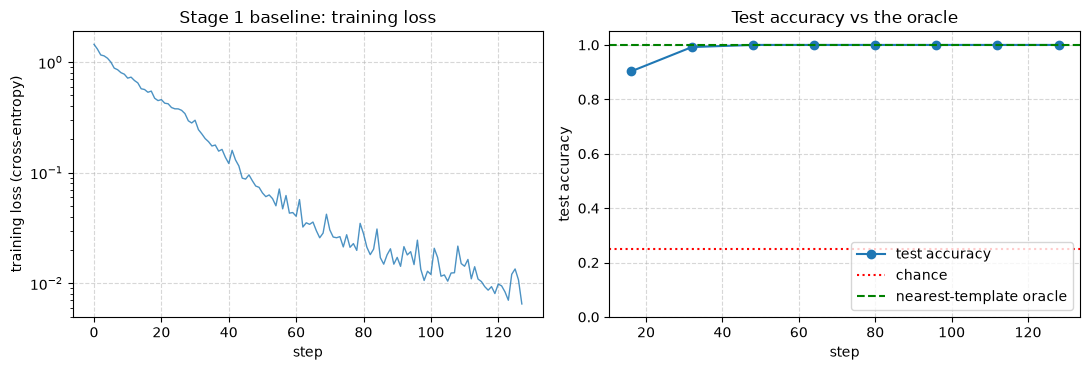

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].semilogy(hist_loss, lw=1, alpha=0.8)
ax[0].set_xlabel("step")
ax[0].set_ylabel("training loss (cross-entropy)")
ax[0].set_title("Stage 1 baseline: training loss")
ax[0].grid(True, ls="--", alpha=0.5)

ax[1].plot(hist_step, hist_acc, "o-", label="test accuracy")
ax[1].axhline(1.0 / N_CLASSES, color="r", ls=":", label="chance")
ax[1].axhline(oracle, color="g", ls="--", label="nearest-template oracle")
ax[1].set_xlabel("step")
ax[1].set_ylabel("test accuracy")
ax[1].set_ylim(0, 1.05)
ax[1].set_title("Test accuracy vs the oracle")
ax[1].legend(loc="lower right")
ax[1].grid(True, ls="--", alpha=0.5)

plt.tight_layout()

> **Observe:** 
> The loss drops about 100 times (from about X to about X/100), and test accuracy reaches the same level as the nearest-template oracle. So the model has learned the rule behind the labels, which is the best it can do.
> But be careful about what this result means. We made this task easy on purpose, so the notebook runs in a few seconds.
> This result shows that our training code works correctly. It does not show that this model is a good model.
> Accuracy becomes a meaningful number only on real CIFAR-10 on the GPU node. There we use the same code and the same training step. Only make_data changes.


### Throughput, measured honestly

This is an HPML course, so we do not report a number we cannot defend. The rules from
Week 1, restated because every timing cell in this course obeys them:

1. **Warm up.** The first call compiles; timing it measures XLA, not your model.
2. **`block_until_ready()`.** JAX dispatch is asynchronous. Without this you time how
   fast Python can *queue* work, which is fast and meaningless.
3. **Repeat and take a median.** One sample is not a measurement.
4. **Report a rate** and name the device.

Watch for something on the side here: each new batch size triggers a **recompile**,
because shape is part of the treedef and therefore part of the `jit` cache key. We time
compilation separately so you can see it. That is Week 4's lesson arriving early.


In [19]:
def measure(batch_size, repeats=5):
    xb, yb = X_tr[:batch_size], Y_tr[:batch_size]
    m, s = eqx.nn.make_with_state(ResNet)(jax.random.key(1))
    o = optimizer.init(eqx.filter(m, eqx.is_inexact_array))

    t0 = time.perf_counter()                       # 1. warm up == compile for this shape
    _, _, _, l = train_step(m, s, o, xb, yb)
    l.block_until_ready()                          # 2. actually wait for it
    t_compile = time.perf_counter() - t0

    ts = []
    for _ in range(repeats):                       # 3. repeat
        t0 = time.perf_counter()
        _, _, _, l = train_step(m, s, o, xb, yb)
        l.block_until_ready()
        ts.append(time.perf_counter() - t0)
    t_step = float(np.median(ts))                  # 3. median
    return t_compile, t_step


sizes = [16, 32, 64, 128, 256]
rows = []
print(f"{'batch':>6}  {'compile (s)':>11}  {'step (ms)':>10}  {'examples/sec':>13}")
print("-" * 46)
for bs in sizes:
    t_compile, t_step = measure(bs)
    rate = bs / t_step                             # 4. a rate
    rows.append((bs, t_compile, t_step, rate))
    print(f"{bs:>6}  {t_compile:>11.2f}  {t_step * 1e3:>10.2f}  {rate:>13,.0f}")

print(f"\ndevice: {jax.devices()[0].device_kind}")
print("note: EVERY row paid a fresh compile -- new shape, new jit cache entry.")

 batch  compile (s)   step (ms)   examples/sec
----------------------------------------------


    16         0.69        5.41          2,960


    32         0.47        9.38          3,413
    64         0.02       16.25          3,939


   128         0.49       31.38          4,079


   256         0.51       52.15          4,909

device: cpu
note: EVERY row paid a fresh compile -- new shape, new jit cache entry.


throughput at batch 16: 2,960 ex/s
throughput at batch 256: 4,909 ex/s
speedup from batching: 1.66x


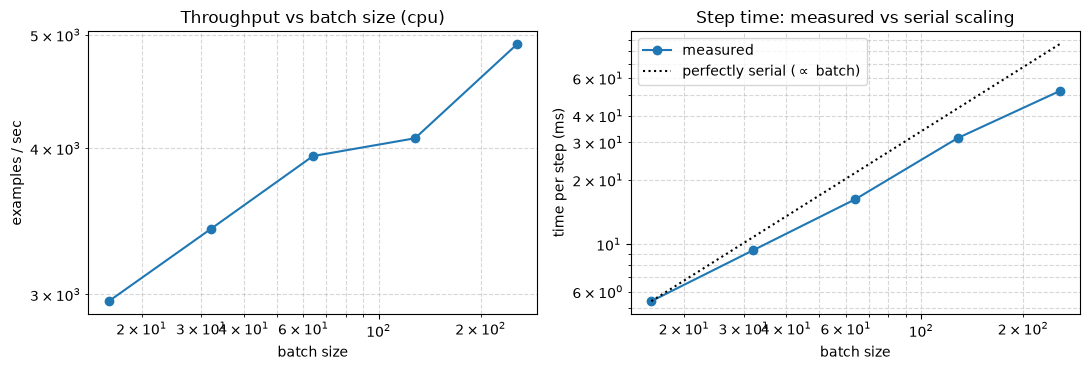

In [20]:
bs_arr = np.array([r[0] for r in rows])
rate_arr = np.array([r[3] for r in rows])
step_arr = np.array([r[2] for r in rows]) * 1e3

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].loglog(bs_arr, rate_arr, "o-")
ax[0].set_xlabel("batch size")
ax[0].set_ylabel("examples / sec")
ax[0].set_title(f"Throughput vs batch size ({jax.devices()[0].device_kind})")
ax[0].grid(True, ls="--", alpha=0.5, which="both")

ax[1].loglog(bs_arr, step_arr, "o-", label="measured")
ideal = step_arr[0] * bs_arr / bs_arr[0]
ax[1].loglog(bs_arr, ideal, "k:", label="perfectly serial ($\\propto$ batch)")
ax[1].set_xlabel("batch size")
ax[1].set_ylabel("time per step (ms)")
ax[1].set_title("Step time: measured vs serial scaling")
ax[1].legend()
ax[1].grid(True, ls="--", alpha=0.5, which="both")

plt.tight_layout()

print(f"throughput at batch {bs_arr[0]}: {rate_arr[0]:,.0f} ex/s")
print(f"throughput at batch {bs_arr[-1]}: {rate_arr[-1]:,.0f} ex/s")
print(f"speedup from batching: {rate_arr[-1] / rate_arr[0]:.2f}x")

> **Observe:** Look at this plot carefully. The result is not what you might expect.
> We made the batch 16 times bigger, but throughput (examples per second) went up by much less than 2×. 
> Check the printed speedup. The exact number changes from run to run, because timing on a CPU is noisy. 
> So bigger batches help, but only a little.
> The step-time curve stays below the "perfectly serial" line, and the gap grows as the batch gets bigger. 
> This is because each step has a fixed cost (for example, launching the computation), and a bigger batch shares that cost across more examples.
> But the curve never becomes flat.
> What this means: the CPU is already fully busy at batch size 16. 
> A CPU has only a few cores, so there is no idle hardware left to use. 
> If you double the batch, you just double the work. 
> There is no "knee" (the point where the curve bends and flattens) in this plot, 
> and we should not pretend there is one.
> On the GPU node, the same experiment looks different. 
> A GPU has thousands of cores, and a small batch leaves most of them idle. 
> So throughput goes up quickly at first, then flattens at a clear knee. 
> In Lab 2 on the real GPU, you will find this knee. 
> It is the batch size where one device is fully used, and the only way to go faster is to use more devices.
> That is Week 5. From then on, the main problem is no longer computation. It is communication between devices.


### 🔬 Exercise 3

**Exercise:** the step above uses a constant learning rate. Replace `optax.adamw(3e-3)`
with a **chained** optimizer that (a) clips gradients to a global norm of 1.0 and
(b) uses a warmup + cosine-decay schedule peaking at `3e-3`. Retrain and compare the
loss curve against the constant-LR run.

Then answer two questions:

1. **Which of the four states changed size** when you switched optimizers? Don't guess.
    Count the leaves before and after. The answer may surprise you.
2. Which state is the **biggest**, and why does that matter for a client that has to
    upload its update in Week 10?

optimizer state, constant adamw :  19,753
optimizer state, clip + schedule:  19,754   (+1)

model parameters :   9,876
optimizer state  :  19,754   <- about 2x the model
batch statistics :     165
final test acc: 1.000


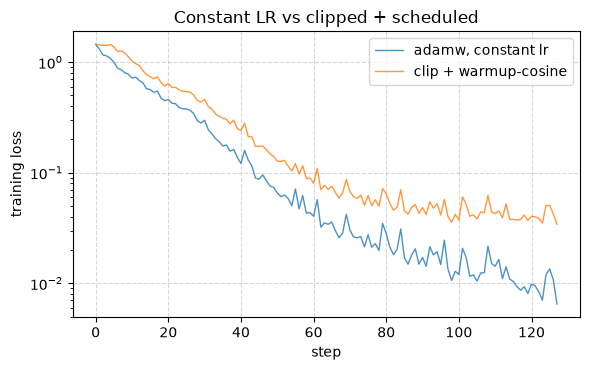

In [44]:
# --- Reference solution (instructor: blank this out for students) ---

STEPS_TOTAL = EPOCHS * (len(X_tr) // BATCH)
sched = optax.warmup_cosine_decay_schedule(
    init_value=0.0, peak_value=3e-3, warmup_steps=STEPS_TOTAL // 10, decay_steps=STEPS_TOTAL)

sched_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=sched),
)

@eqx.filter_jit
def sched_step(model, state, opt_state, x, y):
    (loss, state), grads = eqx.filter_value_and_grad(loss_fn, has_aux=True)(model, state, x, y)
    updates, opt_state = sched_optimizer.update(grads, opt_state,
                                                eqx.filter(model, eqx.is_inexact_array))
    return eqx.apply_updates(model, updates), state, opt_state, loss

m2, s2 = eqx.nn.make_with_state(ResNet)(jax.random.key(1))
o2 = sched_optimizer.init(eqx.filter(m2, eqx.is_inexact_array))

loss2 = []
for epoch in range(EPOCHS):
    perm = np.asarray(jax.random.permutation(jax.random.fold_in(train_key, epoch), len(X_tr)))
    for i in range(0, len(X_tr) - BATCH + 1, BATCH):
        idx = perm[i:i + BATCH]
        m2, s2, o2, l = sched_step(m2, s2, o2, X_tr[idx], Y_tr[idx])
        loss2.append(float(l))

plt.figure(figsize=(6, 3.8))
plt.semilogy(hist_loss, lw=1, alpha=0.8, label="adamw, constant lr")
plt.semilogy(loss2, lw=1, alpha=0.8, label="clip + warmup-cosine")
plt.xlabel("step"); plt.ylabel("training loss")
plt.title("Constant LR vs clipped + scheduled")
plt.legend(); plt.grid(True, ls="--", alpha=0.5); plt.tight_layout()

# the state-size question: count BEFORE and AFTER, don't guess
sz = lambda t: sum(x.size for x in jax.tree.leaves(t) if eqx.is_array(x))
params2 = eqx.filter(m2, eqx.is_inexact_array)
before = sz(optimizer.init(params2))          # constant-LR adamw
after = sz(o2)                                # clip + scheduled adamw

print(f"optimizer state, constant adamw : {before:>7,}")
print(f"optimizer state, clip + schedule: {after:>7,}   (+{after - before})")
print()
print(f"model parameters : {sz(params2):>7,}")
print(f"optimizer state  : {after:>7,}   <- about 2x the model")
print(f"batch statistics : {sz(s2):>7,}")
print(f"final test acc: {float(evaluate(m2, s2, X_te, Y_te)):.3f}")

  > **Observation**
  >
  > **1. Almost nothing changed size.** The optimizer state grew by exactly **one number**.
  > Clipping has no state (`EmptyState`). The schedule adds one step counter, because it
  > needs to know which step it is on. The other three states did not change at all.
  >
  > **2. The optimizer state is the biggest**, about **2× the model**. But that is because
  > of **Adam** (it stores two moments, `mu` and `nu`, each the size of the model), not
  > because of `chain`. It was already this big with the constant-LR `adamw`. The size of
  > the optimizer state depends mainly on **which** optimizer you pick (SGD: 0,
  > momentum: 1×, Adam: 2×), not on how you chain it.
  >
  > **Why this matters in Week 10:** the optimizer state is only **one client's own
  > gradient history**. If a client uploaded it, it would send about **3× as much data**
  > (parameters + two moments), and the server has no use for it. So a client uploads only
  > its **parameters** (or the update to them), however you build the optimizer.

---

## 6. Batch statistics are a real state (and they will bite you)

Back to the odd one out. Batch normalization keeps a running estimate of each channel's
mean and variance, updated by the **forward pass** as an exponential moving average with
momentum $\rho$:

$$\hat{\mu}_{t+1} = \rho\,\hat{\mu}_t + (1 - \rho)\,\mu_{\text{batch}}$$

At training time the layer normalizes with the *batch's* statistics; at inference time
it uses the *running* ones. So the running estimates need to have actually converged by
the time you evaluate. Their time constant is roughly $1/(1-\rho)$ steps: at
$\rho = 0.99$ that is ~100 steps, at $\rho = 0.9$ only ~10.

Our training run is 128 steps. That is comfortable for $\rho = 0.9$ and marginal for
$\rho = 0.99$ — the library default in many frameworks. Let us train the identical model
at both and evaluate each **two ways**: once with running statistics (`inference_mode`,
what you would deploy) and once with batch statistics (what training sees).

If the two evaluations disagree, the model is fine and the *state* is stale.


In [22]:
def train_variant(bn_momentum, epochs=EPOCHS, seed=1):
    m, s = eqx.nn.make_with_state(ResNet)(jax.random.key(seed), bn_momentum=bn_momentum)
    o = optimizer.init(eqx.filter(m, eqx.is_inexact_array))
    losses = []
    for epoch in range(epochs):
        perm = np.asarray(jax.random.permutation(jax.random.fold_in(train_key, epoch), len(X_tr)))
        for i in range(0, len(X_tr) - BATCH + 1, BATCH):
            idx = perm[i:i + BATCH]
            m, s, o, l = train_step(m, s, o, X_tr[idx], Y_tr[idx])
            losses.append(float(l))
    return m, s, losses


@eqx.filter_jit
def eval_batch_stats(model, state, x, y):
    # NOT inference_mode: normalize with THIS batch's statistics
    logits, _ = batched_forward(model, state, x)
    return jnp.mean(jnp.argmax(logits, axis=-1) == y)


results = {}
print(f"{'BN momentum':>12}  {'train loss':>11}  {'acc (running)':>14}  {'acc (batch)':>12}")
print("-" * 56)
for rho in (0.99, 0.9):
    m, s, losses = train_variant(rho)
    a_run = float(evaluate(m, s, X_te, Y_te))            # running stats  (deployment)
    a_bat = float(eval_batch_stats(m, s, X_te, Y_te))    # batch stats    (training view)
    results[rho] = (np.mean(losses[-16:]), a_run, a_bat, losses)
    print(f"{rho:>12}  {np.mean(losses[-16:]):>11.4f}  {a_run:>14.3f}  {a_bat:>12.3f}")

 BN momentum   train loss   acc (running)   acc (batch)
--------------------------------------------------------


        0.99       0.0100           0.855         1.000


         0.9       0.0100           1.000         1.000


rho=0.99: batch-stat acc exceeds running-stat acc by 0.145
rho=0.9 : the same gap is 0.000


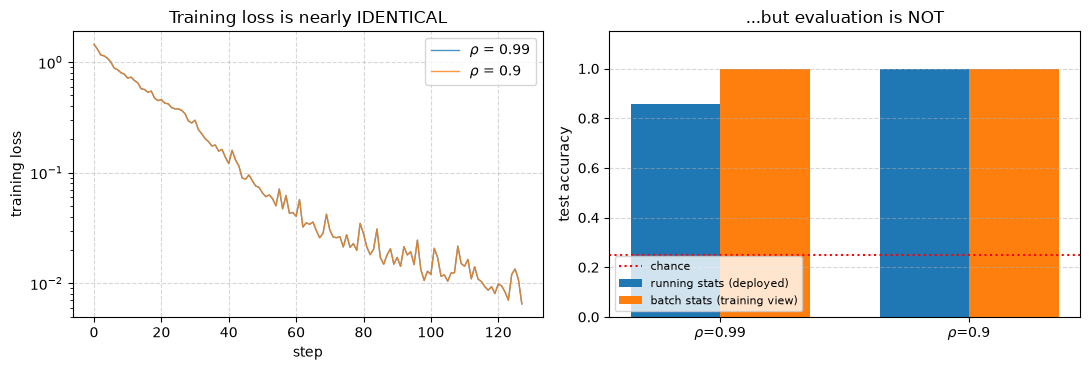

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

for rho in (0.99, 0.9):
    ax[0].semilogy(results[rho][3], lw=1, alpha=0.8, label=f"$\\rho$ = {rho}")
ax[0].set_xlabel("step"); ax[0].set_ylabel("training loss")
ax[0].set_title("Training loss is nearly IDENTICAL")
ax[0].legend(); ax[0].grid(True, ls="--", alpha=0.5)

labels = [f"$\\rho$={r}" for r in (0.99, 0.9)]
xpos = np.arange(2)
ax[1].bar(xpos - 0.18, [results[r][1] for r in (0.99, 0.9)], 0.36, label="running stats (deployed)")
ax[1].bar(xpos + 0.18, [results[r][2] for r in (0.99, 0.9)], 0.36, label="batch stats (training view)")
ax[1].axhline(1.0 / N_CLASSES, color="r", ls=":", label="chance")
ax[1].set_xticks(xpos); ax[1].set_xticklabels(labels)
ax[1].set_ylabel("test accuracy"); ax[1].set_ylim(0, 1.15)
ax[1].set_title("...but evaluation is NOT")
ax[1].legend(fontsize=8, loc="lower left"); ax[1].grid(True, ls="--", alpha=0.5, axis="y")

plt.tight_layout()

gap = results[0.99][2] - results[0.99][1]
print(f"rho=0.99: batch-stat acc exceeds running-stat acc by {gap:.3f}")
print(f"rho=0.9 : the same gap is {results[0.9][2] - results[0.9][1]:.3f}")

> **Observe:** the two runs have **the same training loss** and **different test
> accuracy**. At $\rho = 0.99$ the running statistics have not caught up within 128
> steps, so the deployed model is measurably worse than the model actually is — the
> parameters are fine, the *third state* is stale. Nothing raised an error; the only
> symptom was a number being lower than it should be. This is why the four states get
> four names.
>
> Now carry it into the federated setting. A batch-norm running average is a summary of
> **one client's local data distribution**. Under non-IID data those summaries disagree
> across clients, and averaging them produces statistics describing a distribution *no
> client actually has*. That is a real failure mode with a real fix — **FedBN**, which
> keeps batch-norm state local and averages everything else — and it is Week 11. You are
> looking at the reason it exists.

(Week 11): A BatchNorm running mean describes one client's data. For example, X-rays from hospital A may be
brighter than X-rays from hospital B. If we average the two, we get a brightness that matches neither hospital. FedBN solves this by keeping the BatchNorm layers on each client and averaging only the rest of the model.


---

## 7. Grain: feeding the device

A saturated device is a hungry one, and a training loop that stalls waiting on Python is
a training loop wasting a GPU. **Grain** is Google's deterministic input pipeline for
JAX: random-access data source → transformations → batches, with the shuffle **seeded**
so an epoch is reproducible and checkpoint-resumable.

Our slicing-with-a-permutation loop above was fine for 1024 in-memory examples. It does
not survive contact with a dataset that does not fit in RAM, needs augmentation on
worker processes, or has to resume mid-epoch. Grain is the same pipeline written in a
way that does.

Note the deliberate parallel to everything else today: the transformations are
**composed**, and the randomness is **explicit and seeded**.


In [45]:
import grain

# a "source" is anything with __len__ and __getitem__ -- here, a numpy array.
# On the GPU node this is where CIFAR-10 goes; the rest of the pipeline is unchanged.
source = np.asarray(X_tr)

dataset = (
    grain.MapDataset.source(source)
    .shuffle(seed=42)                      # explicit seed -> reproducible epoch
    .batch(batch_size=BATCH)
)

print("pipeline:", type(dataset).__name__)
print("batches per epoch:", len(dataset), f"(= {len(source)} // {BATCH})")

b0 = np.asarray(dataset[0])
print("batch 0 shape:", b0.shape, "<- random access, not just iteration")

print()
print("determinism: rebuild the pipeline with the same seed, get the same batch")
again = grain.MapDataset.source(source).shuffle(seed=42).batch(batch_size=BATCH)
print("  identical:", bool(np.array_equal(b0, np.asarray(again[0]))))
print("  different seed gives a different batch:", not bool(np.array_equal(
    b0, np.asarray(grain.MapDataset.source(source).shuffle(seed=0).batch(batch_size=BATCH)[0]))))

print()
n_seen = sum(np.asarray(b).shape[0] for b in dataset)
print(f"iterating one epoch: {n_seen} examples in {len(dataset)} batches")

pipeline: BatchMapDataset
batches per epoch: 16 (= 1024 // 64)
batch 0 shape: (64, 3, 32, 32) <- random access, not just iteration

determinism: rebuild the pipeline with the same seed, get the same batch
  identical: True
  different seed gives a different batch: True

iterating one epoch: 1024 examples in 16 batches


> **Observe:** a Grain pipeline is a *composed, seeded, random-access* object — `len()`
> works, `[i]` works, and the same seed reproduces the same epoch. Contrast that with an
> opaque iterator you can only step forward: in Week 10 you will need to say "client 7
> sees this Dirichlet-skewed shard, in this order, and can resume after dropping out."
> That sentence needs a pipeline with an index, which is why the ecosystem has this
> library.


---

## 8. Flax NNX: the road not taken


Equinox is not the only library for neural networks in JAX. Another popular one is Flax NNX. We don't use it in this course,
but it is worth knowing for two reasons:

1. To read other people's code. A lot of JAX code, especially from Google, uses Flax.
2. To understand our choice. We should know what we gain and what we give up by using Equinox.

The two libraries start from opposite ideas.

Equinox: "A model is a value (a PyTree). Pass state in and get it back out."

```
  y, state = model(x, state)                  # you get a new state back
  model = eqx.apply_updates(model, updates)   # you get a new model back
```

  The model never changes. To "change" it, you create a new model and keep that one.

  Flax NNX: "A model is a normal Python object. Just change it."

  model = nnx.Linear(2, 3, rngs=nnx.Rngs(0))
  optimizer.update(grads)    # the model changes in place

  Like in PyTorch, the model object is changed in place. BatchNorm statistics are also updated inside the model automatically.



In [25]:
from flax import nnx

class NNXNet(nnx.Module):
    def __init__(self, din, dout, rngs):
        self.linear = nnx.Linear(din, dout, rngs=rngs)
        self.bn = nnx.BatchNorm(dout, rngs=rngs)
        self.n_calls = nnx.Variable(jnp.array(0))     # arbitrary mutable state

    def __call__(self, x):
        self.n_calls[...] = self.n_calls[...] + 1     # in-place mutation. No state arg.
        return self.bn(self.linear(x))


net = NNXNet(4, 3, nnx.Rngs(0))
_ = net(jnp.ones((8, 4)))
_ = net(jnp.ones((8, 4)))
print("called twice; counter =", int(net.n_calls[...]), "-- the object mutated itself")
print("note the signature: __call__(self, x). No `state` in, no `state` out.")

# crossing into JAX-land: split the object into (static graph, params, everything else)
graphdef, params, rest = nnx.split(net, nnx.Param, ...)
print()
print("nnx.split ->")
print("  graphdef:", type(graphdef).__name__, "(static structure)")
print("  params  :", len(jax.tree.leaves(params)), "leaves")
print("  rest    :", len(jax.tree.leaves(rest)), "leaves (batch stats + counter)")
print("  bn.mean is a:", type(net.bn.mean).__name__, "<- typed as BatchStat, not Param")
print()
print("nnx.merge(graphdef, params, rest) rebuilds the object:",
      type(nnx.merge(graphdef, params, rest)).__name__)

called twice; counter = 2 -- the object mutated itself
note the signature: __call__(self, x). No `state` in, no `state` out.

nnx.split ->
  graphdef: GraphDef (static structure)
  params  : 4 leaves
  rest    : 3 leaves (batch stats + counter)
  bn.mean is a: BatchStat <- typed as BatchStat, not Param

nnx.merge(graphdef, params, rest) rebuilds the object: NNXNet


Notice that NNX arrives at the *same destination*: to enter a JAX transformation the
state must become PyTrees, and NNX's `Param` / `BatchStat` variable types are drawing
exactly the distinction our four-state table draws. The difference is **when** you pay:
NNX defers the split to the transformation boundary; Equinox never hides it.

| | **Equinox** | **Flax NNX** |
|---|---|---|
| Model is | a PyTree (frozen dataclass) | a Python object, reference semantics |
| State updates | returned explicitly: `x, state = f(x, state)` | in-place mutation: `self.count[...] += 1` |
| Crossing into `jit`/`grad` | `filter_jit` / `filter_grad` partition by leaf type | `nnx.split` / `nnx.merge`, or `nnx.jit` |
| Params vs batch stats | **you** separate them (`make_with_state`) | typed variables (`nnx.Param`, `nnx.BatchStat`) |
| Surprises live in | verbosity — you thread state by hand | the object graph — aliasing, mutation order |
| Feels like | JAX | PyTorch |

**Why the spine picks Equinox.** Not because it is better in the abstract — NNX's
ergonomics are genuinely nicer for a big single-machine model. We pick it because this
course's hardest ideas *are* state-management ideas. "Which state does a client ship?
Which stays local? What does averaging batch statistics from non-IID clients even
mean?" — those questions are the syllabus for Weeks 9–13. A framework that answers them
for you is doing your homework. Equinox's verbosity is the point: state you must write
down is state you must think about.

If you would rather use NNX for your final project, do. Just be able to say what
`nnx.split` returns and why.


> **Observe:** both libraries must produce PyTrees of parameters and PyTrees of
> non-parameter state before JAX will touch them — NNX just does it at the boundary
> rather than at every call. The functional core is not a stylistic preference of one
> library; it is what JAX *requires*. Equinox declines to hide it, which is what makes
> it the right teaching substrate for Stage 4.


---

## 9. Diffrax and Lineax: differentiability is not just for networks

Two more libraries, briefly, because they show what the JAX ecosystem is really for. Both
are by the author of Equinox, and both are built from `eqx.Module`s — so everything you
learned in Section 1 applies unchanged.

The deep point is this: **JAX's transformations do not know what a neural network is.**
`grad` differentiates *programs*. If your program is an ODE solve or a linear solve, it
differentiates that. This is why "Scientific ML" is a JAX story, and why gradients can
flow through a physics simulator sitting in the middle of a model.

**Diffrax** solves differential equations, differentiably. Take
$\dot{y} = -a y$, $y(0) = 1$, whose exact solution $y(t) = e^{-at}$ we know — so we can
check both the solve *and* the gradient against the truth:

$$y(1) = e^{-a} \qquad\Longrightarrow\qquad \frac{\partial y(1)}{\partial a} = -e^{-a}$$


In [26]:
import diffrax as dfx

def vector_field(t, y, a):
    return -a * y

def solve(a, ts):
    return dfx.diffeqsolve(
        dfx.ODETerm(vector_field), dfx.Dopri5(),
        t0=0.0, t1=1.0, dt0=0.1, y0=jnp.array(1.0), args=a,
        saveat=dfx.SaveAt(ts=ts),
        stepsize_controller=dfx.PIDController(rtol=1e-8, atol=1e-10),
    ).ys

a_true = 2.0
ts = jnp.linspace(0.0, 1.0, 6)
ys = solve(a_true, ts)
exact = jnp.exp(-a_true * ts)

print(f"{'t':>5}  {'diffrax':>12}  {'exact e^-2t':>12}  {'abs err':>10}")
print("-" * 45)
for t, y, e in zip(ts, ys, exact):
    print(f"{float(t):>5.2f}  {float(y):>12.8f}  {float(e):>12.8f}  {abs(float(y - e)):>10.2e}")

# now differentiate THROUGH the solver
def y_at_1(a):
    return dfx.diffeqsolve(
        dfx.ODETerm(vector_field), dfx.Dopri5(),
        t0=0.0, t1=1.0, dt0=0.1, y0=jnp.array(1.0), args=a,
        stepsize_controller=dfx.PIDController(rtol=1e-8, atol=1e-10),
        adjoint=dfx.RecursiveCheckpointAdjoint(),
    ).ys[0]

g_ad = float(jax.grad(y_at_1)(a_true))
g_exact = float(-np.exp(-a_true))
print(f"\nd y(1) / da  via jax.grad through the solver : {g_ad:.10f}")
print(f"d y(1) / da  exact  (-e^-a)                  : {g_exact:.10f}")
print(f"relative error                               : {abs(g_ad - g_exact) / abs(g_exact):.2e}")

    t       diffrax   exact e^-2t     abs err
---------------------------------------------
 0.00    1.00000000    1.00000000    0.00e+00
 0.20    0.67032170    0.67032003    1.67e-06
 0.40    0.44932875    0.44932896    2.09e-07
 0.60    0.30119413    0.30119419    5.96e-08
 0.80    0.20189643    0.20189652    8.94e-08
 1.00    0.13533494    0.13533528    3.43e-07



d y(1) / da  via jax.grad through the solver : -0.1353352964
d y(1) / da  exact  (-e^-a)                  : -0.1353352832
relative error                               : 9.72e-08


max |grad - exact| over the sweep: 7.850877720150251e-08


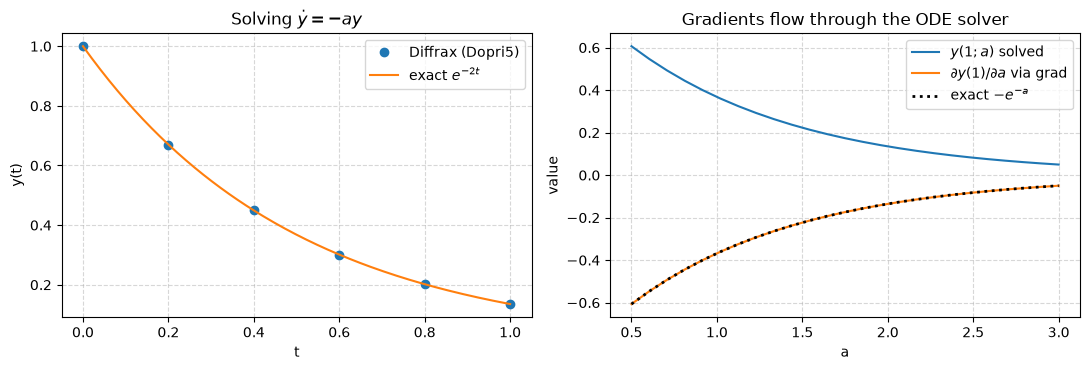

In [27]:
a_grid = np.linspace(0.5, 3.0, 25)
y_vals = np.array([float(y_at_1(float(a))) for a in a_grid])
g_vals = np.array([float(jax.grad(y_at_1)(float(a))) for a in a_grid])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].plot(np.asarray(ts), np.asarray(ys), "o", label="Diffrax (Dopri5)")
tt = np.linspace(0, 1, 200)
ax[0].plot(tt, np.exp(-a_true * tt), "-", label="exact $e^{-2t}$")
ax[0].set_xlabel("t"); ax[0].set_ylabel("y(t)")
ax[0].set_title("Solving $\\dot{y} = -ay$")
ax[0].legend(); ax[0].grid(True, ls="--", alpha=0.5)

ax[1].plot(a_grid, y_vals, label="$y(1;a)$ solved")
ax[1].plot(a_grid, g_vals, label="$\\partial y(1)/\\partial a$ via grad")
ax[1].plot(a_grid, -np.exp(-a_grid), "k:", lw=2, label="exact $-e^{-a}$")
ax[1].set_xlabel("a"); ax[1].set_ylabel("value")
ax[1].set_title("Gradients flow through the ODE solver")
ax[1].legend(); ax[1].grid(True, ls="--", alpha=0.5)

plt.tight_layout()
print("max |grad - exact| over the sweep:", float(np.max(np.abs(g_vals + np.exp(-a_grid)))))

**Lineax** does the same for linear systems: `solve(A, b)` as a differentiable,
JIT-able operation with a real solver library behind it (CG, LU, QR, least-squares) and
*tags* that let you tell it what you know about $A$ — symmetric, positive definite,
triangular — so it can pick the right algorithm instead of guessing.


In [28]:
import lineax as lx

A = jnp.array([[3.0, 1.0], [1.0, 2.0]])       # symmetric positive definite
b = jnp.array([9.0, 8.0])

op = lx.MatrixLinearOperator(A, tags=lx.positive_semidefinite_tag)
sol = lx.linear_solve(op, b, solver=lx.CG(rtol=1e-10, atol=1e-12))

print("lineax CG :", np.asarray(sol.value))
print("np.linalg :", np.linalg.solve(np.asarray(A), np.asarray(b)))
print("residual ||Ax - b||:", float(jnp.linalg.norm(A @ sol.value - b)))

# and it is differentiable: d/db of sum(x) where Ax = b  =>  A^-T 1
def total(bb):
    return jnp.sum(lx.linear_solve(op, bb, solver=lx.CG(rtol=1e-10, atol=1e-12)).value)

g = jax.grad(total)(b)
print()
print("grad_b sum(A^-1 b) via lineax :", np.asarray(g))
print("exact  A^-T @ ones            :", np.asarray(jnp.linalg.solve(A.T, jnp.ones(2))))

lineax CG : [1.9999999 3.0000002]
np.linalg : [2. 3.]
residual ||Ax - b||: 0.0



grad_b sum(A^-1 b) via lineax : [0.2        0.39999998]


exact  A^-T @ ones            : [0.20000002 0.4       ]


> **Observe:** the ODE gradient matches $-e^{-a}$ to ~7 decimal places across the whole
> sweep, and the linear-solve gradient matches $A^{-T}\mathbf{1}$ to float32 precision
> (~$10^{-8}$ — these are single-precision arrays, so that *is* the noise floor). Nobody wrote
> a derivative rule for "Dopri5 with adaptive steps" — `grad` differentiated the solver
> the same way it differentiates your ResNet, because to JAX they are both just
> programs. That is the ecosystem's actual thesis, and it is why the same machinery
> serves both a CIFAR classifier and a physics simulator.


### 🔬 Exercise 4

**Exercise:** fit an ODE parameter by gradient descent — a miniature "neural ODE" with
exactly one parameter. Generate noisy observations of $y(t) = e^{-a^{\star}t}$ with
$a^{\star} = 1.7$ at ten time points, then recover $a^{\star}$ by minimizing squared
error with Optax, differentiating **through the Diffrax solver**.

Report the recovered $a$ and confirm the loss decreases. You are combining Section 2
(Optax) with Section 9 (Diffrax) — and this is exactly the structure of a Neural ODE,
except the vector field would be a network.


true a       : 1.7
recovered a  : 1.7150
abs error    : 0.0150
loss 1.20e-01 -> 1.32e-04

Is that error a bug? No -- check against the actual least-squares optimum,
which is what we asked the optimizer to find (the data is NOISY):


  best a on a grid scan : 1.720   (loss 1.327e-04)
  gradient descent found: 1.715
  => the optimizer converged; the gap to 1.7 is observation noise, not error.


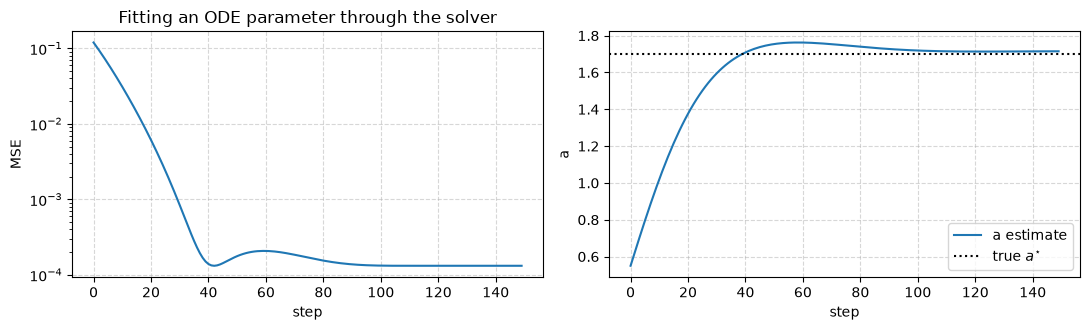

In [29]:
# --- Reference solution (instructor: blank this out for students) ---

A_STAR = 1.7
ts_obs = jnp.linspace(0.1, 1.0, 10)
obs = jnp.exp(-A_STAR * ts_obs) + 0.01 * jax.random.normal(jax.random.key(5), (10,))

def predict(a):
    return dfx.diffeqsolve(
        dfx.ODETerm(vector_field), dfx.Dopri5(),
        t0=0.0, t1=1.0, dt0=0.1, y0=jnp.array(1.0), args=a,
        saveat=dfx.SaveAt(ts=ts_obs),
        stepsize_controller=dfx.PIDController(rtol=1e-8, atol=1e-10),
        adjoint=dfx.RecursiveCheckpointAdjoint(),
    ).ys

@jax.jit
def ode_loss(a):
    return jnp.mean((predict(a) - obs) ** 2)

value_and_grad_loss = jax.jit(jax.value_and_grad(ode_loss))

a = 0.5                                   # deliberately far from the truth
tx_fit = optax.adam(0.05)
st = tx_fit.init(a)

traj, lo = [], []
for i in range(150):                      # 60 steps is NOT converged -- check, do not assume
    l, g = value_and_grad_loss(a)
    upd, st = tx_fit.update(g, st)
    a = optax.apply_updates(a, upd)
    traj.append(float(a)); lo.append(float(l))

print(f"true a       : {A_STAR}")
print(f"recovered a  : {float(a):.4f}")
print(f"abs error    : {abs(float(a) - A_STAR):.4f}")
print(f"loss {lo[0]:.2e} -> {lo[-1]:.2e}")
print()
print("Is that error a bug? No -- check against the actual least-squares optimum,")
print("which is what we asked the optimizer to find (the data is NOISY):")
grid = np.linspace(1.5, 1.9, 41)
losses_grid = np.array([float(ode_loss(float(gv))) for gv in grid])
a_ls = float(grid[losses_grid.argmin()])
print(f"  best a on a grid scan : {a_ls:.3f}   (loss {losses_grid.min():.3e})")
print(f"  gradient descent found: {float(a):.3f}")
print(f"  => the optimizer converged; the gap to {A_STAR} is observation noise, not error.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].semilogy(lo); ax[0].set_xlabel("step"); ax[0].set_ylabel("MSE")
ax[0].set_title("Fitting an ODE parameter through the solver")
ax[0].grid(True, ls="--", alpha=0.5)
ax[1].plot(traj, label="a estimate")
ax[1].axhline(A_STAR, color="k", ls=":", label="true $a^{\\star}$")
ax[1].set_xlabel("step"); ax[1].set_ylabel("a"); ax[1].legend()
ax[1].grid(True, ls="--", alpha=0.5)
plt.tight_layout()

---

## Summary

We built the codebase the rest of the course edits.

- **A model is a PyTree.** That single design decision is why `jax.grad(loss)(model)`
  works with no framework machinery, and why the gradient of a model is *a model*. When
  a transformation rejects your module, ask which leaf is not an array — then
  `eqx.partition` / `eqx.filter_jit` / `eqx.filter_grad`.
- **An optimizer is a gradient transformation** `(init, update)`. We rebuilt
  `optax.sgd(momentum=0.9)` from scratch and matched it to *exactly* zero difference.
  Optimizers `chain`, and their state is a PyTree you own — which is what makes the FL
  question "what does the client actually upload?" askable at all.
- **The four states are four things**: parameters · optimizer state · batch statistics ·
  PRNG. We kept them in four objects. Section 6 showed the cost of forgetting: two runs
  with identical training loss and different test accuracy, because the batch statistics
  were stale — no error, just a worse number.
- **The training loop is a contract**: `(model, state, opt_state, batch) -> (model,
  state, opt_state, loss)`. Pure in, pure out. Week 9 lifts it into a Flower client
  nearly verbatim.
- **We measured honestly**: warm up, `block_until_ready`, median, report a rate and name
  the device. Throughput rose with batch size and then flattened — and past that knee,
  more speed means more devices, which is Week 5.
- **Equinox vs Flax NNX** is a bet about where state lives. We chose the framework that
  refuses to hide it, because hidden state is precisely what Weeks 9–13 are about.
- **`grad` differentiates programs, not networks.** Diffrax and Lineax gave gradients
  through an ODE solver and a linear solve that matched the analytic answers.

**The thread.** Today's separation of the four states is not tidiness — it is the
Stage 4 setup. In Week 9, "run FedAvg" will mean: ship *parameters*, keep *optimizer
state* local, argue about *batch statistics* (Week 11's FedBN), and `fold_in` the *PRNG*
per client. Four decisions, one per state. And in Week 12, per-example gradient clipping
for DP-SGD is a `vmap` over the same per-example function you already wrote — because
you wrote the model for one example and let a transformation do the batching.

**Next week** we take this exact loop and make it fast: `vmap` and `scan` in anger, PRNG
discipline at scale, the `jit` recompilation traps (you saw one already — every batch
size paid a fresh compile), and the profiler. Stage 1 gets finished. Then Week 5 takes
it off one device.

### Further Exercises

1. **Swap the head for a real spine change.** Add a second resolution stage (stride-2
   conv, 16 → 32 channels) to `ResNet`. How do parameter count, batch-stat count, and
   examples/sec each change? Which grew fastest, and why?
2. **The recompile trap, deliberately.** Time `train_step` on batch sizes 64, 65, 64.
   Explain why the third call is fast and the second is not, then use
   `train_step._fun.__wrapped__` or `jax.clear_caches()` to investigate. (Week 4.)
3. **Local SGD, three weeks early.** Split `X_tr` into 4 disjoint shards. Train 4 copies
   of the model independently for $\tau$ steps, then average their *parameters* with
   `jax.tree.map`. Sweep $\tau \in \{1, 5, 20, 100\}$ and plot final accuracy vs $\tau$.
   At $\tau = 1$ you have (approximately) data-parallel SGD; at $\tau = 100$ you have
   something much worse. You have just built Week 7's lab.
4. **Average the batch statistics too — and watch it break.** Repeat exercise 3, but
   make the four shards **non-IID** (shard $i$ gets mostly class $i$). Average the batch
   statistics along with the parameters, then compare against keeping them local. You
   have just derived FedBN (Week 11) and its motivation.
5. **NNX head-to-head.** Reimplement `ResBlock` in Flax NNX and train it to the same
   accuracy. Which parts got shorter? Where did the state go? Would you still be able to
   answer "what does this client upload?" as easily?
